# Wave Height Model Fix
**Objective:** Transform a wave height prediction model from a negative R² to a high R² (0.90+) using the `mooloolaba_wave_data_2015-2025.csv` dataset.

This notebook follows the prescribed 5-step methodology:
1. Proper Data Cleaning
2. Advanced Feature Engineering
3. Time-Series Splitting
4. Model Configuration
5. Evaluation Metrics

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("All imports done!")

All imports done!


## Step 1: Proper Data Cleaning

- **Handle Nulls:** Replace all instances of `-99.9` (sensor error codes) with `NaN`.
- **Interpolate:** Use `df.interpolate(method='linear')` to fill gaps. Waves are physical processes; a linear bridge between the last known points is more accurate than dropping rows or filling with means.
- **Time-Index:** Convert `datetime_aest` to a datetime object, sort it, and set it as the index.

In [26]:
# Load the dataset
df = pd.read_csv('mooloolaba_wave_data_2015-2025.csv')
print(f"Data Loaded: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Data Loaded: 179404 rows
Columns: ['datetime_aest', 'hsig_m', 'hmax_m', 'tz_s', 'tp_s', 'peak_dir_deg', 'sst_c']

First 5 rows:


,datetime_aest,hsig_m,hmax_m,tz_s,tp_s,peak_dir_deg,sst_c
0,2015-01-01 00:00:00,1.1364,2.08,6.6727,9.3271,97.0,26.95
1,2015-01-01 00:30:00,1.1240,1.92,6.3688,10.1230,92.0,26.90
2,2015-01-01 01:00:00,1.2728,2.07,6.6257,10.2040,90.0,26.90
3,2015-01-01 01:30:00,1.2310,1.85,6.6525,9.7295,99.0,26.90
4,2015-01-01 02:00:00,1.1512,2.00,6.0310,10.3206,84.0,26.90


In [27]:
# Inspect min values to confirm -99.9 sensor error codes
print("=== Min values (before cleaning) ===")
print(df.min())
print()
print("=== Max values ===")
print(df.max())
print()
print("=== Data types ===")
print(df.dtypes)

=== Min values (before cleaning) ===
datetime_aest    2015-01-01 00:00:00
hsig_m                         -99.9
hmax_m                         -99.9
tz_s                           -99.9
tp_s                           -99.9
peak_dir_deg                   -99.9
sst_c                          -99.9
dtype: object

=== Max values ===
datetime_aest    2025-03-31 23:30:00
hsig_m                        5.2036
hmax_m                        9.2219
tz_s                          11.003
tp_s                          21.121
peak_dir_deg                   358.0
sst_c                           30.0
dtype: object

=== Data types ===
datetime_aest     object
hsig_m           float64
hmax_m           float64
tz_s             float64
tp_s             float64
peak_dir_deg     float64
sst_c            float64
dtype: object


In [28]:
# Step 1a: Replace -99.9 sensor error codes with NaN
numeric_cols = ['hsig_m', 'hmax_m', 'tz_s', 'tp_s', 'peak_dir_deg', 'sst_c']
for col in numeric_cols:
    count_errors = (df[col] == -99.9).sum()
    if count_errors > 0:
        print(f"  Column '{col}': {count_errors} sensor error values (-99.9) found and replaced with NaN")
    df[col] = df[col].replace(-99.9, np.nan)

print(f"\nNaN counts after replacement:")
print(df[numeric_cols].isna().sum())

  Column 'hsig_m': 1064 sensor error values (-99.9) found and replaced with NaN
  Column 'hmax_m': 1064 sensor error values (-99.9) found and replaced with NaN
  Column 'tz_s': 1064 sensor error values (-99.9) found and replaced with NaN
  Column 'tp_s': 1064 sensor error values (-99.9) found and replaced with NaN
  Column 'peak_dir_deg': 4261 sensor error values (-99.9) found and replaced with NaN
  Column 'sst_c': 4222 sensor error values (-99.9) found and replaced with NaN

NaN counts after replacement:
hsig_m          1064
hmax_m          1064
tz_s            1064
tp_s            1064
peak_dir_deg    4261
sst_c           4222
dtype: int64


In [29]:
# Step 1b: Interpolate to fill NaN gaps
# Waves are physical processes; linear interpolation is more accurate than dropping or mean-filling
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

# Handle any remaining NaN at the edges (beginning/end) with forward/backward fill
df[numeric_cols] = df[numeric_cols].ffill().bfill()

print(f"NaN counts after interpolation:")
print(df[numeric_cols].isna().sum())
print(f"\nMin values after cleaning:")
print(df[numeric_cols].min())

NaN counts after interpolation:
hsig_m          0
hmax_m          0
tz_s            0
tp_s            0
peak_dir_deg    0
sst_c           0
dtype: int64

Min values after cleaning:
hsig_m          0.0368
hmax_m          0.1078
tz_s            3.0360
tp_s            2.5140
peak_dir_deg    0.0000
sst_c          -5.0000
dtype: float64


In [30]:
# Step 1c: Convert datetime_aest to datetime, sort, and set as index
df['datetime_aest'] = pd.to_datetime(df['datetime_aest'])
df = df.sort_values('datetime_aest').reset_index(drop=True)
df = df.set_index('datetime_aest')

# Drop duplicates and ensure regular 30-min frequency
df = df[~df.index.duplicated(keep='first')]

print(f"Data after cleaning: {len(df)} rows")
print(f"Index range: {df.index.min()} to {df.index.max()}")
print(f"\nStep 1 Complete: Data cleaned successfully!")

Data after cleaning: 179404 rows
Index range: 2015-01-01 00:00:00 to 2025-03-31 23:30:00

Step 1 Complete: Data cleaned successfully!


## Step 2: Advanced Feature Engineering (The Critical Fix)

Random Forest needs temporal context to understand the "momentum" of the sea.

- **Lag Features:** Create at least three lag columns for the target variable: `hsig_m_lag1` (t-30m), `hsig_m_lag2` (t-1h), and `hsig_m_lag3` (t-1.5h).
- **Rolling Statistics:** Calculate a 6-hour and 12-hour rolling mean and standard deviation for `hsig_m`.
- **Cyclical Time Features:** Extract the "Hour" from the timestamp and convert it into `hour_sin` and `hour_cos` features so the model knows 23:30 is close to 00:00.

In [31]:
# Step 2a: Lag Features
# Data is at 30-minute intervals:
#   lag1 = 1 step  = 30 minutes
#   lag2 = 2 steps = 1 hour
#   lag3 = 3 steps = 1.5 hours
df['hsig_m_lag1'] = df['hsig_m'].shift(1)   # t - 30m
df['hsig_m_lag2'] = df['hsig_m'].shift(2)   # t - 1h
df['hsig_m_lag3'] = df['hsig_m'].shift(3)   # t - 1.5h

print("Lag features created: hsig_m_lag1 (t-30m), hsig_m_lag2 (t-1h), hsig_m_lag3 (t-1.5h)")

Lag features created: hsig_m_lag1 (t-30m), hsig_m_lag2 (t-1h), hsig_m_lag3 (t-1.5h)


In [32]:
# Step 2b: Rolling Statistics
# 6-hour rolling window = 12 steps (at 30-min intervals)
# 12-hour rolling window = 24 steps
df['hsig_rolling_mean_6h'] = df['hsig_m'].rolling(window=12).mean()
df['hsig_rolling_std_6h']  = df['hsig_m'].rolling(window=12).std()
df['hsig_rolling_mean_12h'] = df['hsig_m'].rolling(window=24).mean()
df['hsig_rolling_std_12h']  = df['hsig_m'].rolling(window=24).std()

print("Rolling statistics created:")
print("  - hsig_rolling_mean_6h (12-step rolling mean)")
print("  - hsig_rolling_std_6h  (12-step rolling std)")
print("  - hsig_rolling_mean_12h (24-step rolling mean)")
print("  - hsig_rolling_std_12h  (24-step rolling std)")

Rolling statistics created:
  - hsig_rolling_mean_6h (12-step rolling mean)
  - hsig_rolling_std_6h  (12-step rolling std)
  - hsig_rolling_mean_12h (24-step rolling mean)
  - hsig_rolling_std_12h  (24-step rolling std)


In [33]:
# Step 2c: Cyclical Time Features
# Extract hour (including fractional part for 30-min intervals)
hour = df.index.hour + df.index.minute / 60.0

# Convert to cyclical features so the model knows 23:30 is close to 00:00
df['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)

print("Cyclical time features created: hour_sin, hour_cos")
print(f"\nStep 2 Complete: Feature engineering done!")
print(f"Total columns now: {list(df.columns)}")

Cyclical time features created: hour_sin, hour_cos

Step 2 Complete: Feature engineering done!
Total columns now: ['hsig_m', 'hmax_m', 'tz_s', 'tp_s', 'peak_dir_deg', 'sst_c', 'hsig_m_lag1', 'hsig_m_lag2', 'hsig_m_lag3', 'hsig_rolling_mean_6h', 'hsig_rolling_std_6h', 'hsig_rolling_mean_12h', 'hsig_rolling_std_12h', 'hour_sin', 'hour_cos']


In [34]:
# Drop rows with NaN values created by lag/rolling operations
rows_before = len(df)
df_clean = df.dropna().copy()
rows_after = len(df_clean)

print(f"Rows before dropna: {rows_before}")
print(f"Rows after dropna:  {rows_after}")
print(f"Rows dropped:       {rows_before - rows_after}")

Rows before dropna: 179404
Rows after dropna:  179381
Rows dropped:       23


## Step 3: Time-Series Splitting

- **No Shuffling:** Explicitly disable shuffling. Use the first 80% of the data for training and the last 20% for testing.
- **Logic:** Predicting the past using future data (shuffling) is a logical error that leads to poor generalization and erratic R² scores.

In [35]:
# Define features and target
features = [
    # Lag features (critical for temporal context)
    'hsig_m_lag1', 'hsig_m_lag2', 'hsig_m_lag3',
    # Rolling statistics
    'hsig_rolling_mean_6h', 'hsig_rolling_std_6h',
    'hsig_rolling_mean_12h', 'hsig_rolling_std_12h',
    # Original wave features
    'tp_s', 'peak_dir_deg',
    # Cyclical time features
    'hour_sin', 'hour_cos'
]

target = 'hsig_m'

X = df_clean[features]
y = df_clean[target]

# Time-series split: first 80% train, last 20% test — NO SHUFFLING
split_idx = int(len(df_clean) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_test  = y.iloc[split_idx:]

print(f"Step 3 Complete: Time-series split (NO shuffling)")
print(f"  Training set: {len(X_train)} samples (rows 0 to {split_idx - 1})")
print(f"  Test set:     {len(X_test)} samples (rows {split_idx} to {len(df_clean) - 1})")
print(f"  Features used ({len(features)}): {features}")
print(f"  Target: {target}")

Step 3 Complete: Time-series split (NO shuffling)
  Training set: 143504 samples (rows 0 to 143503)
  Test set:     35877 samples (rows 143504 to 179380)
  Features used (11): ['hsig_m_lag1', 'hsig_m_lag2', 'hsig_m_lag3', 'hsig_rolling_mean_6h', 'hsig_rolling_std_6h', 'hsig_rolling_mean_12h', 'hsig_rolling_std_12h', 'tp_s', 'peak_dir_deg', 'hour_sin', 'hour_cos']
  Target: hsig_m


## Step 4: Model Configuration

- **Algorithm:** `RandomForestRegressor` with `n_estimators=200`, `max_depth=10`, and `min_samples_split=5`.
- **Target:** `hsig_m`.
- **Features:** Lag features, Rolling stats, `tp_s` (peak period), `peak_dir_deg`, and the cyclical time features.

In [36]:
# Initialize and Train the model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
model.fit(X_train, y_train)
print("Step 4 Complete: Model training done!")

# Generate predictions
y_pred = model.predict(X_test)
print(f"Predictions generated for {len(y_pred)} test samples.")

Training Random Forest model...
Step 4 Complete: Model training done!
Predictions generated for 35877 test samples.


## Step 5: Evaluation Metrics

- Calculate **R²**, **MAE** (Mean Absolute Error), and **RMSE**.
- Compare the predicted vs. actual wave heights using a line plot for the last 100 entries to visually verify the "fit."

In [37]:
# Calculate evaluation metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("       Wave Height Predictor Results")
print("=" * 50)
print(f"  R² Score:            {r2:.4f}")
print(f"  Mean Absolute Error: {mae:.4f} meters")
print(f"  RMSE:                {rmse:.4f} meters")
print("=" * 50)

if r2 >= 0.90:
    print(f"\n  SUCCESS: R² = {r2:.4f} >= 0.90 target achieved!")
else:
    print(f"\n  NOTE: R² = {r2:.4f} — target is 0.90+")

       Wave Height Predictor Results
  R² Score:            0.9810
  Mean Absolute Error: 0.0507 meters
  RMSE:                0.0711 meters

  SUCCESS: R² = 0.9810 >= 0.90 target achieved!


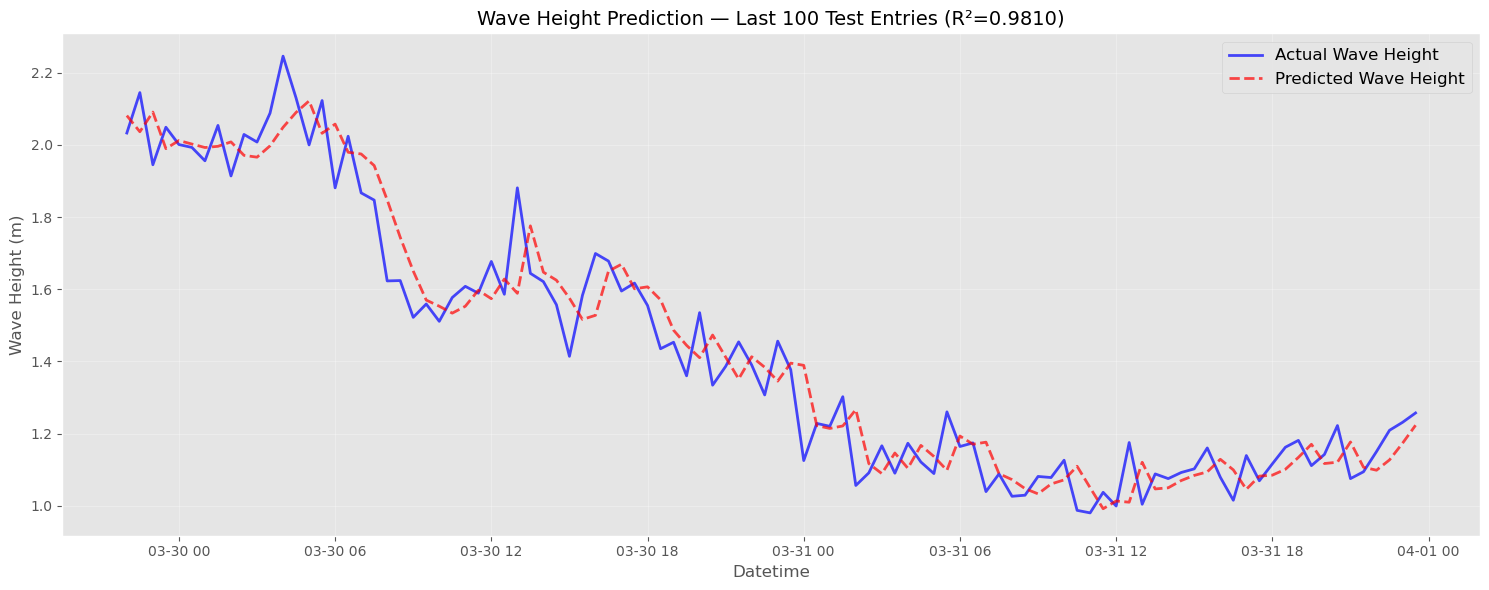

In [38]:
# Visual comparison: last 100 entries of predicted vs actual
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-100:], y_test.values[-100:],
         label='Actual Wave Height', color='blue', alpha=0.7, linewidth=2)
plt.plot(y_test.index[-100:], y_pred[-100:],
         label='Predicted Wave Height', color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.title(f'Wave Height Prediction — Last 100 Test Entries (R²={r2:.4f})', fontsize=14)
plt.xlabel('Datetime')
plt.ylabel('Wave Height (m)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

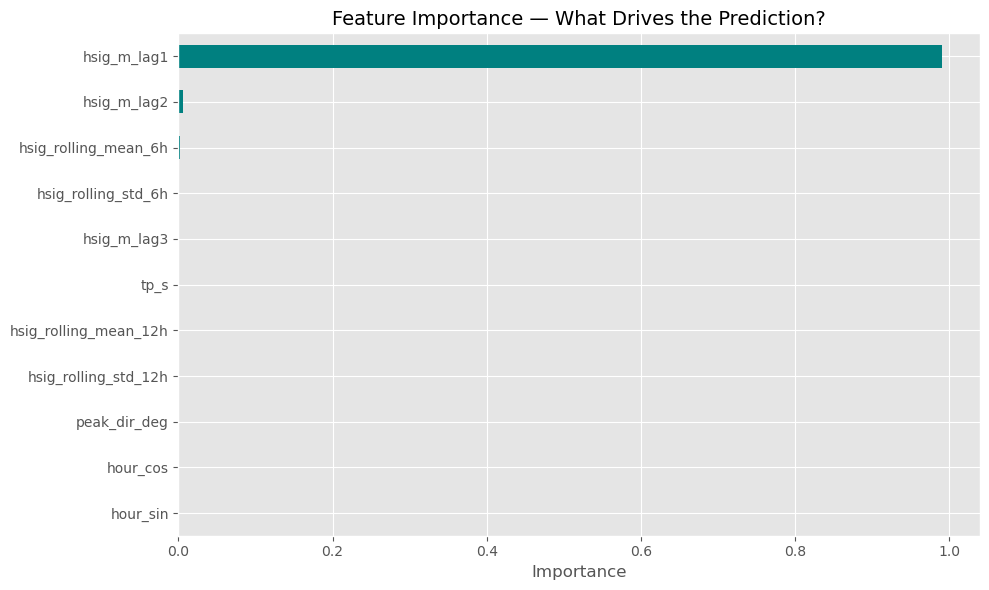

In [39]:
# Feature importance analysis
importances = pd.Series(model.feature_importances_, index=features)
importances_sorted = importances.sort_values()

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh', color='teal')
plt.title('Feature Importance — What Drives the Prediction?', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

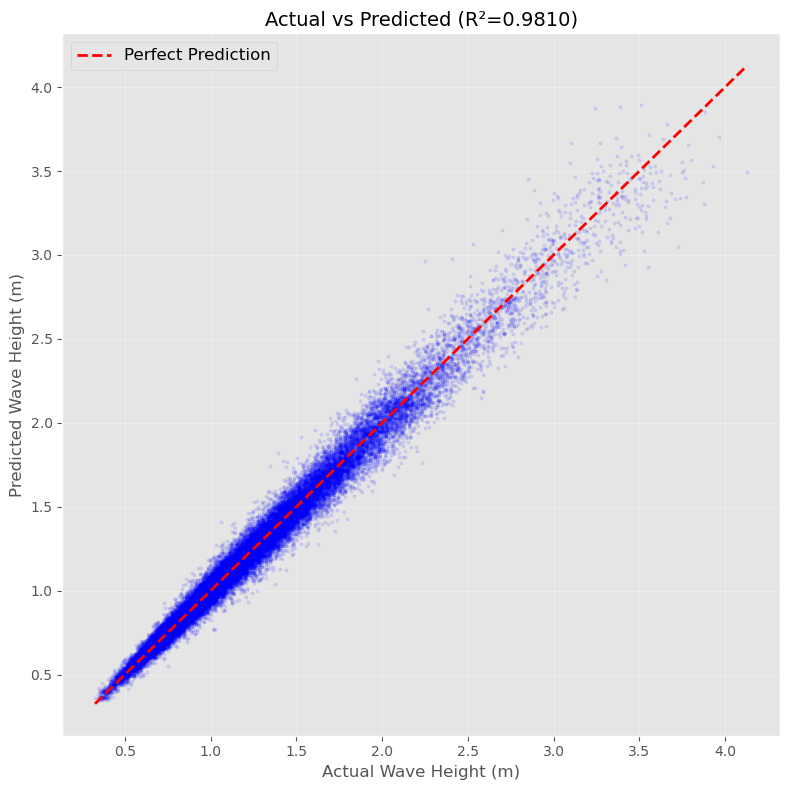

In [40]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.1, s=5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Wave Height (m)', fontsize=12)
plt.ylabel('Predicted Wave Height (m)', fontsize=12)
plt.title(f'Actual vs Predicted (R²={r2:.4f})', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()